# Lisbon Housing Baseline: Foreign Investment Context

This notebook reproduces the district-quarter baseline model using the clean merged dataset. Run the cells from top to bottom. The analysis code is intentionally visible and editable.

## 1. Environment Setup

Define project-relative paths and the output folder.

In [14]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'clean' / 'district_quarter_full_dataset.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Input file:', DATA_PATH)
print('Outputs folder:', OUTPUT_DIR)

Project root: /Users/henrikpeuker/Documents/GitHub/lisbon-housing-baseline-pipeline
Input file: /Users/henrikpeuker/Documents/GitHub/lisbon-housing-baseline-pipeline/data/clean/district_quarter_full_dataset.csv
Outputs folder: /Users/henrikpeuker/Documents/GitHub/lisbon-housing-baseline-pipeline/outputs


## 2. Import Libraries

Import the libraries used for data handling, fixed-effects models, and figures.

In [15]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS, PooledOLS

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

## 3. Configure Reproducibility

In [16]:
RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)
print('Random seed:', RANDOM_SEED)

Random seed: 2026


## 4. Load or Create Input Data

Load the clean district-quarter dataset and rename its national variables to the names used in the model formulas.

In [17]:
raw_data = pd.read_csv(DATA_PATH, parse_dates=['date'])
column_mapping = {
    'log_price_sale': 'log_price',
    'ine_transaction_count_national': 'transaction_count',
    'ine_transaction_value_thousands_national': 'transaction_value_thousands',
    'ine_price_value_index_national': 'value_index',
    'ine_volume_index_national': 'volume_index',
    'mortgage_rate_fixed_pct_national': 'mortgage_rate_fixed',
    'fdi_realestate_transactions_meur_national': 'fdi_real_estate_transactions_meur',
}
panel_data = raw_data.rename(columns=column_mapping).copy()
panel_data['quarter'] = panel_data['date'].dt.to_period('Q')
panel_data = panel_data.sort_values(['district', 'quarter'])
panel_data['price_growth_qoq'] = panel_data.groupby('district')['log_price'].diff()
panel_data['price_growth_yoy'] = panel_data.groupby('district')['log_price'].diff(4)
panel_data['log_price_lag1'] = panel_data.groupby('district')['log_price'].shift(1)
panel_data['qdate'] = panel_data['quarter'].dt.to_timestamp()
panel_data['t'] = panel_data['quarter'].astype(int)
panel_data['t'] = panel_data['t'] - panel_data['t'].min()
print(f'Loaded {len(panel_data):,} district-quarter rows')

Loaded 820 district-quarter rows


## 5. Inspect Data

Check dimensions, coverage, sample rows, and missing values before modeling.

In [18]:
print('Shape:', panel_data.shape)
print('Districts:', panel_data['district'].nunique())
print('Date range:', panel_data['date'].min().date(), 'to', panel_data['date'].max().date())
display(panel_data.head())
model_columns = ['log_price', 'volume_index', 'fdi_real_estate_transactions_meur', 'mortgage_rate_fixed']
display(panel_data[model_columns].isna().sum().to_frame('missing_rows'))

Shape: (820, 24)
Districts: 20
Date range: 2015-01-01 to 2025-01-01


,district,period,year,quarter,date,price_sqm_sale,price_sqm_rental,log_price,price_growth_qoq,price_growth_yoy,transaction_count,transaction_value_thousands,value_index,volume_index,mortgage_rate_fixed,fdi_real_estate_transactions_meur,fdi_realestate_stock_meur_national,fdi_total_stock_meur_national,construction_cost_yoy_growth_pct_national,population_national,unemployment_rate_pct_regional,log_price_lag1,qdate,t
0,aveiro,1T2015,2015,2015Q1,2015-01-01,782.666667,3.700000,6.662707,NaN,NaN,21762.0,2662680.0,101.193890,96.176071,NaN,319.12,12554.79,125514.70,0.700000,10381838.0,14.2,NaN,2015-01-01,0
1,aveiro,2T2015,2015,2015Q2,2015-04-01,789.000000,3.766667,6.670766,0.008059,NaN,20614.0,2509888.0,100.699240,91.102542,NaN,297.14,12851.93,125514.70,0.833333,10381838.0,12.4,6.662707,2015-04-01,1
2,aveiro,3T2015,2015,2015Q3,2015-07-01,825.000000,3.933333,6.715383,0.044617,NaN,22928.0,2697752.0,97.312800,101.329150,NaN,319.68,13171.62,125514.70,1.133333,10381838.0,12.3,6.670766,2015-07-01,2
3,aveiro,4T2015,2015,2015Q4,2015-10-01,823.333333,3.900000,6.713361,-0.002022,NaN,25205.0,3071762.0,100.794070,111.392237,NaN,405.34,13576.96,125514.70,1.200000,10381838.0,12.5,6.715383,2015-10-01,3
4,aveiro,1T2016,2016,2016Q1,2016-01-01,804.666667,4.000000,6.690428,-0.022933,0.027721,24926.0,3001077.0,99.576915,110.159211,NaN,434.90,14011.86,127838.92,1.366667,10356516.0,12.8,6.713361,2016-01-01,4


,missing_rows
log_price,0
volume_index,0
fdi_real_estate_transactions_meur,0
mortgage_rate_fixed,300


## 6. Run Core Processing

Estimate the six baseline specifications. The full two-way fixed-effects model with national controls is expected to fail because those controls do not vary across districts within a quarter.

In [19]:
def r2_rmse(result, y):
    residuals = result.resids.values
    sse = np.sum(residuals ** 2)
    sst = np.sum((y.values - y.values.mean()) ** 2)
    return 1 - sse / sst, np.sqrt(np.mean(residuals ** 2))

panel = panel_data.set_index(['district', 'qdate'])
panel.index = panel.index.set_names(['district', 'quarter'])
results = {}

def add_result(name, model, y):
    result = model.fit(cov_type='clustered', cluster_entity=True)
    results[name] = (result, *r2_rmse(result, y))

add_result('0_pooled_ols', PooledOLS.from_formula('log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur', data=panel), panel['log_price'])
add_result('0b_entity_fe_only', PanelOLS.from_formula('log_price ~ 1 + EntityEffects', data=panel), panel['log_price'])
add_result('1_twfe_decomposition', PanelOLS.from_formula('log_price ~ 1 + EntityEffects + TimeEffects', data=panel), panel['log_price'])
add_result('2_entity_fe_trend_covars', PanelOLS.from_formula('log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur + EntityEffects', data=panel), panel['log_price'])

mortgage_panel = panel.dropna(subset=['mortgage_rate_fixed'])
add_result('3_entity_fe_trend_mortgage_restricted', PanelOLS.from_formula('log_price ~ 1 + t + mortgage_rate_fixed + volume_index + fdi_real_estate_transactions_meur + EntityEffects', data=mortgage_panel), mortgage_panel['log_price'])

spec4_error = None
try:
    add_result('4_full_twfe_with_covars', PanelOLS.from_formula('log_price ~ 1 + mortgage_rate_fixed + volume_index + fdi_real_estate_transactions_meur + EntityEffects + TimeEffects', data=mortgage_panel), mortgage_panel['log_price'])
except Exception as error:
    spec4_error = str(error)

growth_panel = panel.dropna(subset=['price_growth_qoq'])
add_result('5_growth_convergence', PanelOLS.from_formula('price_growth_qoq ~ 1 + log_price_lag1 + volume_index + fdi_real_estate_transactions_meur + EntityEffects', data=growth_panel), growth_panel['price_growth_qoq'])

summary_rows = []
for name, (result, r2_total, rmse) in results.items():
    summary_rows.append({'spec': name, 'n_obs': int(result.nobs), 'r2_total': round(r2_total, 4), 'r2_within': round(result.rsquared_within, 4), 'rmse': round(rmse, 4)})
summary = pd.DataFrame(summary_rows)
display(summary)
print('Spec 4 failed as expected.' if spec4_error else 'Spec 4 unexpectedly succeeded.')

,spec,n_obs,r2_total,r2_within,rmse
0,0_pooled_ols,820,0.1990,0.7225,0.3868
1,0b_entity_fe_only,820,0.7246,0.0000,0.2268
2,1_twfe_decomposition,820,0.9267,0.0000,0.1170
3,2_entity_fe_trend_covars,820,0.9236,0.7225,0.1195
4,3_entity_fe_trend_mortgage_restricted,520,0.9777,0.8289,0.0689
5,5_growth_convergence,800,0.1195,0.0593,0.0267


Spec 4 failed as expected.


## 7. Validate Results

In [20]:
assert len(panel) == 820, f'Expected 820 rows, found {len(panel)}'
assert panel.index.get_level_values('district').nunique() == 20
assert np.isfinite(summary[['r2_total', 'rmse']].to_numpy()).all()
print('Validation passed: 820 rows, 20 districts, and finite model summaries.')

Validation passed: 820 rows, 20 districts, and finite model summaries.


## 8. Save Outputs

Save the same tables and figures as the Python pipeline.

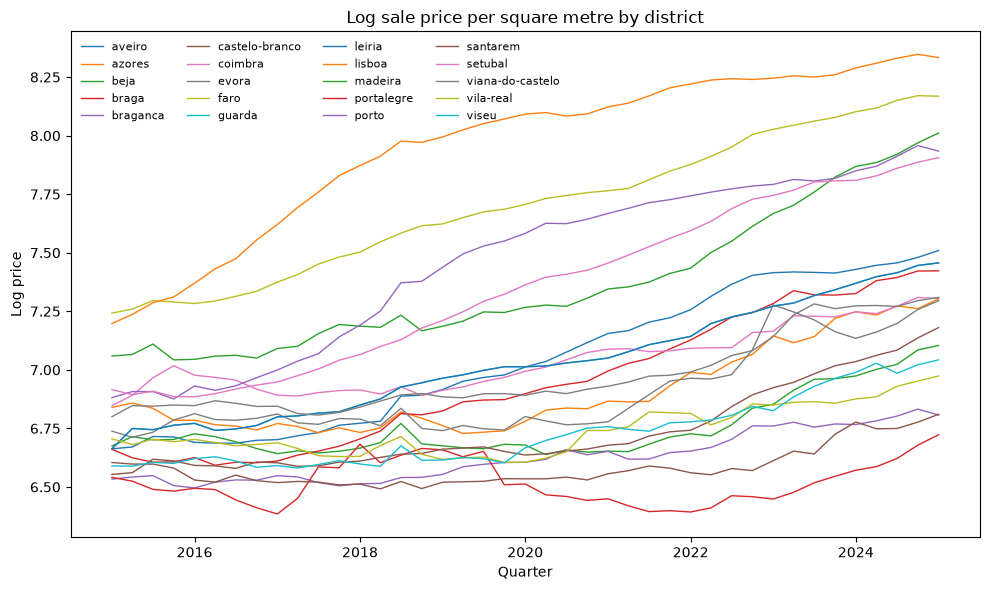

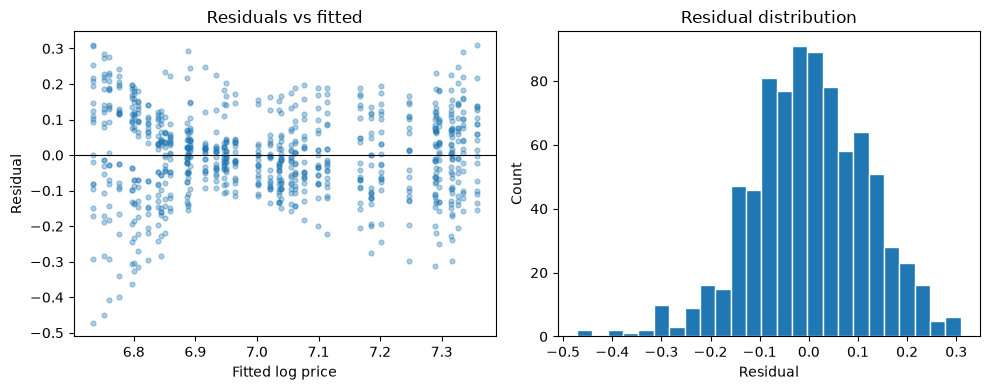

Saved tables and figures to: /Users/henrikpeuker/Documents/GitHub/lisbon-housing-baseline-pipeline/outputs


In [21]:
panel.to_csv(OUTPUT_DIR / 'district_quarter_panel_final.csv')
summary.to_csv(OUTPUT_DIR / 'model_comparison_table.csv', index=False)
for name in ['2_entity_fe_trend_covars', '3_entity_fe_trend_mortgage_restricted', '5_growth_convergence']:
    result = results[name][0]
    coefficients = pd.DataFrame({'param': result.params.index, 'coef': result.params.values, 'std_err': result.std_errors.values, 't_stat': result.tstats.values, 'p_value': result.pvalues.values})
    coefficients.to_csv(OUTPUT_DIR / f'coefs_{name}.csv', index=False)

plot_panel = panel.drop(columns=['quarter']).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
for district, group in plot_panel.groupby('district'):
    ax.plot(group['quarter'], group['log_price'], linewidth=1, label=district)
ax.set(title='Log sale price per square metre by district', xlabel='Quarter', ylabel='Log price')
ax.legend(ncol=4, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig1_district_price_trends.png', dpi=180)
plt.show()
plt.close(fig)

trend_result = results['2_entity_fe_trend_covars'][0]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(trend_result.fitted_values.iloc[:, 0], trend_result.resids, alpha=0.35, s=12)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set(xlabel='Fitted log price', ylabel='Residual', title='Residuals vs fitted')
axes[1].hist(trend_result.resids, bins=25, edgecolor='white')
axes[1].set(xlabel='Residual', ylabel='Count', title='Residual distribution')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig2_residual_diagnostics.png', dpi=180)
plt.show()
plt.close(fig)
print('Saved tables and figures to:', OUTPUT_DIR)

## 9. Quick Re-run Cell

Run this final cell after changing and rerunning earlier cells to confirm that all expected output files exist.

In [22]:
expected_outputs = ['district_quarter_panel_final.csv', 'model_comparison_table.csv', 'coefs_2_entity_fe_trend_covars.csv', 'coefs_3_entity_fe_trend_mortgage_restricted.csv', 'coefs_5_growth_convergence.csv', 'fig1_district_price_trends.png', 'fig2_residual_diagnostics.png']
missing_outputs = [name for name in expected_outputs if not (OUTPUT_DIR / name).exists()]
assert not missing_outputs, f'Missing outputs: {missing_outputs}'
print(f'Complete: {len(expected_outputs)} output files are present.')

Complete: 7 output files are present.
